# 프로젝트: 더 멋진 번역기 만들기
> Transformer 기반 한국어 → 영어 번역기 구현 프로젝트입니다.
> PyTorch + SentencePiece를 활용합니다.

## 라이브러리 버전 확인

In [73]:
# Cell 1
import torch
import sentencepiece
import platform

print('PyTorch      :', torch.__version__)
print('SentencePiece:', sentencepiece.__version__)
print('Python       :', platform.python_version())
print('CUDA  사용 가능:', torch.cuda.is_available())
print('MPS   사용 가능:', torch.backends.mps.is_available())

PyTorch      : 2.10.0
SentencePiece: 0.2.1
Python       : 3.11.14
CUDA  사용 가능: False
MPS   사용 가능: True


---
## Step 1. 데이터 다운로드
아래 셀을 실행하면 한영 병렬 코퍼스를 자동으로 다운로드·압축해제합니다.

> **출처**: [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora)

In [74]:
# Cell 2
import os

DATA_DIR = os.path.expanduser('~/work/transformer/data')
os.makedirs(DATA_DIR, exist_ok=True)

url = 'https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz'
gz_path  = os.path.join(DATA_DIR, 'korean-english-park.train.tar.gz')
tar_path = os.path.join(DATA_DIR, 'korean-english-park.train.tar')

# 이미 압축 해제된 파일이 없을 때만 다운로드
if not os.path.exists(os.path.join(DATA_DIR, 'korean-english-park.train.ko')):
    os.system(f'wget -q -O {gz_path} {url}')
    os.system(f'gzip -d -f {gz_path}')
    os.system(f'tar -xvf {tar_path} -C {DATA_DIR}')
    print('다운로드 및 압축 해제 완료')
else:
    print('이미 데이터가 존재합니다.')

KO_FILE = os.path.join(DATA_DIR, 'korean-english-park.train.ko')
EN_FILE = os.path.join(DATA_DIR, 'korean-english-park.train.en')
print('KO:', KO_FILE)
print('EN:', EN_FILE)

이미 데이터가 존재합니다.
KO: /Users/macminim4/work/transformer/data/korean-english-park.train.ko
EN: /Users/macminim4/work/transformer/data/korean-english-park.train.en


---
## Step 2. 데이터 정제 및 토큰화
### 1 중복 데이터 제거
`set` 자료형을 이용해 병렬 쌍의 중복을 제거하고 `cleaned_corpus`에 저장합니다.

In [75]:
# Cell 3
with open(KO_FILE, 'r', encoding='utf-8') as f:
    ko_lines = f.readlines()
with open(EN_FILE, 'r', encoding='utf-8') as f:
    en_lines = f.readlines()

seen = set()
cleaned_corpus = []

for ko, en in zip(ko_lines, en_lines):
    pair = (ko.strip(), en.strip())
    if pair not in seen:
        seen.add(pair)
        cleaned_corpus.append(pair)

print(f'원본 데이터 수    : {len(ko_lines):,}')
print(f'중복 제거 후 수   : {len(cleaned_corpus):,}')

원본 데이터 수    : 94,123
중복 제거 후 수   : 78,941


### 2 정제 함수 정의
- 소문자 변환
- 알파벳 · 한글 · 문장부호만 유지
- 문장부호 양옆 공백 추가
- 앞뒤 공백 제거

In [76]:
# Cell 4
import re

def clean_text(text):
    text = text.lower()                            # 소문자 변환
    text = re.sub(r'[^a-z가-힣\s.,!?]', '', text)  # 허용 문자만 유지
    text = re.sub(r'([.,!?])', r' \1 ', text)      # 문장부호 양옆 공백
    text = text.strip()                            # 앞뒤 공백 제거
    return text

# 확인
print(clean_text('오바마는 대통령이다.'))
print(clean_text('Obama is the President!'))

오바마는 대통령이다 .
obama is the president !


### 3 토큰화 (SentencePiece)
한글/영문 말뭉치를 각각 정제 후 SentencePiece 토크나이저를 학습합니다.

| 특수 토큰 | ID |
|-----------|----|
| `<PAD>`   | 0  |
| `<BOS>`   | 1  |
| `<EOS>`   | 2  |
| `<UNK>`   | 3  |

In [77]:
# Cell 5
import sentencepiece as spm

kor_corpus = [clean_text(pair[0]) for pair in cleaned_corpus]
eng_corpus = [clean_text(pair[1]) for pair in cleaned_corpus]

# 임시 텍스트 파일 저장
with open('kor_corpus.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(kor_corpus))
with open('eng_corpus.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(eng_corpus))

def generate_tokenizer(corpus_file, vocab_size=20000, model_prefix='tokenizer'):
    """SentencePiece 토크나이저 학습 후 반환"""
    spm.SentencePieceTrainer.Train(
        input=corpus_file,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=0,   # <PAD>
        bos_id=1,   # <BOS>
        eos_id=2,   # <EOS>
        unk_id=3,   # <UNK>
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model_prefix}.model')
    return tokenizer

ko_tokenizer = generate_tokenizer('kor_corpus.txt', model_prefix='ko_tokenizer')
en_tokenizer = generate_tokenizer('eng_corpus.txt', model_prefix='en_tokenizer')
en_tokenizer.set_encode_extra_options('bos:eos')  # 타겟: BOS/EOS 자동 추가

print(f'KO vocab size: {ko_tokenizer.GetPieceSize():,}')
print(f'EN vocab size: {en_tokenizer.GetPieceSize():,}')
print('KO sample:', ko_tokenizer.EncodeAsIds('오바마는 대통령이다.'))
print('EN sample:', en_tokenizer.EncodeAsIds('obama is the president .'))

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: ko_tokenizer
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
 

KO vocab size: 20,000
EN vocab size: 20,000
KO sample: [671, 240, 41, 19998]
EN sample: [1, 118, 19, 4, 62, 5, 2]


noise_level: 0
  differential_privacy_clipping_threshold: 0
}
normalizer_spec {
  name: nmt_nfkc
  add_dummy_prefix: 1
  remove_extra_whitespaces: 1
  escape_whitespaces: 1
  normalization_rule_tsv: 
}
denormalizer_spec {}
trainer_interface.cc(355) LOG(INFO) SentenceIterator is not specified. Using MultiFileSentenceIterator.
trainer_interface.cc(186) LOG(INFO) Loading corpus: kor_corpus.txt
trainer_interface.cc(411) LOG(INFO) Loaded all 78940 sentences
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <pad>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: </s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <unk>
trainer_interface.cc(432) LOG(INFO) Normalizing sentences...
trainer_interface.cc(541) LOG(INFO) all chars count=5016275
trainer_interface.cc(552) LOG(INFO) Done: 99.9501% characters are covered.
trainer_interface.cc(562) LOG(INFO) Alphabet size=1186
trainer_interface.cc(563) LOG(INFO) Final character

### 4 토큰 길이 필터링 및 텐서 변환
토큰 길이가 **50 이하**인 문장만 선별하여 `enc_train` / `dec_train` 패딩 텐서로 변환합니다.

In [78]:
# Cell 6
import torch
from torch.nn.utils.rnn import pad_sequence

MAX_LEN = 50

src_corpus, tgt_corpus = [], []

for ko, en in zip(kor_corpus, eng_corpus):
    ko_ids = ko_tokenizer.EncodeAsIds(ko)
    en_ids = en_tokenizer.EncodeAsIds(en)
    if len(ko_ids) <= MAX_LEN and len(en_ids) <= MAX_LEN:
        src_corpus.append(torch.tensor(ko_ids, dtype=torch.long))
        tgt_corpus.append(torch.tensor(en_ids, dtype=torch.long))

enc_train = pad_sequence(src_corpus, batch_first=True, padding_value=0)
dec_train = pad_sequence(tgt_corpus, batch_first=True, padding_value=0)

print(f'필터링 후 데이터 수: {len(src_corpus):,}')
print(f'enc_train shape   : {enc_train.shape}')
print(f'dec_train shape   : {dec_train.shape}')

필터링 후 데이터 수: 73,264
enc_train shape   : torch.Size([73264, 50])
dec_train shape   : torch.Size([73264, 50])


---
## Step 3. 모델 설계
### Positional Encoding
sin/cos 기반 위치 인코딩으로 순서 정보를 임베딩에 더합니다.

In [79]:
# Cell 7
import numpy as np
import torch.nn as nn

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, 2 * (i // 2) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(p) for p in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수: sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수: cos
    return torch.FloatTensor(sinusoid_table)

### PoswiseFeedForwardNet (FFN)
어텐션 이후 각 위치별로 독립적인 비선형 변환을 수행합니다.
구조: `Linear → ReLU → Linear` + Residual & LayerNorm

In [80]:
# Cell 8
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return self.norm(out + residual)

### Multi-Head Attention

In [81]:
# Cell 9
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn

    def forward(self, Q, K, V, mask=None):
        residual = Q
        B = Q.size(0)
        Q = self.W_Q(Q).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        out, attn = self.scaled_dot_product_attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        out = self.W_O(out)
        return self.norm(out + residual), attn

### Encoder

In [82]:
# Cell 10
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn       = PoswiseFeedForwardNet(d_model, d_ff)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        out, attn = self.self_attn(x, x, x, mask)
        out = self.dropout(out)
        out = self.ffn(out)
        return out, attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, vocab_size, max_len=512):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = positional_encoding(max_len, d_model)
        self.layers  = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask=None):
        out = self.embed(x)
        out = out + self.pos_enc[:out.size(1), :].to(out.device)
        attns = []
        for layer in self.layers:
            out, attn = layer(out, mask)
            attns.append(attn)
        return out, attns

### Decoder

In [83]:
# Cell 11
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn        = PoswiseFeedForwardNet(d_model, d_ff)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        out, self_attn  = self.self_attn(x, x, x, tgt_mask)
        out, cross_attn = self.cross_attn(out, enc_out, enc_out, src_mask)
        out = self.dropout(out)
        out = self.ffn(out)
        return out, self_attn, cross_attn


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, vocab_size, max_len=512):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = positional_encoding(max_len, d_model)
        self.layers  = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        out = self.embed(x)
        out = out + self.pos_enc[:out.size(1), :].to(out.device)
        self_attns, cross_attns = [], []
        for layer in self.layers:
            out, s_attn, c_attn = layer(out, enc_out, src_mask, tgt_mask)
            self_attns.append(s_attn)
            cross_attns.append(c_attn)
        return out, self_attns, cross_attns

### Masking & Transformer 전체 모델

In [84]:
# Cell 12
def generate_padding_mask(seq):
    """PAD(0) 위치 마스킹 — (B, 1, 1, T)
    True: 어텐션 허용 / False: 마스킹"""
    return (seq != 0).unsqueeze(1).unsqueeze(2)   # bool tensor


def generate_causal_mask(tgt):
    """Causal(look-ahead) mask + padding mask — (B, 1, T, T)
    디코더 자기 어텐션용: 미래 토큰 참조 방지"""
    B, T = tgt.shape
    # 패딩 마스크: (B, 1, 1, T)
    pad_mask    = (tgt != 0).unsqueeze(1).unsqueeze(2)
    # 인과 마스크: 하삼각 행렬 (1, 1, T, T)  — i번째 토큰은 j<=i만 참조
    causal_mask = torch.tril(torch.ones(T, T, dtype=torch.bool, device=tgt.device))
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
    # 결합: 패딩 AND 미래 미참조 → (B, 1, T, T)
    return pad_mask & causal_mask


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout,
                 enc_vocab_size, dec_vocab_size):
        super().__init__()
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout, enc_vocab_size)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout, dec_vocab_size)
        self.fc_out  = nn.Linear(d_model, dec_vocab_size)

    def forward(self, src, tgt):
        src_mask = generate_padding_mask(src).to(src.device)   # (B,1,1,T_src)
        tgt_mask = generate_causal_mask(tgt).to(tgt.device)    # (B,1,T_tgt,T_tgt)
        enc_out, enc_attns                = self.encoder(src, src_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        out = self.fc_out(dec_out)
        return out, enc_attns, dec_attns, dec_enc_attns

---
## Step 4. 훈련하기
### 1 모델 선언 (2 Layers)

In [85]:
# Cell 13
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('사용 디바이스:', device)

transformer = Transformer(
    n_layers       = 2,
    d_model        = 512,
    n_heads        = 8,
    d_ff           = 2048,
    dropout        = 0.3,
    enc_vocab_size = ko_tokenizer.GetPieceSize(),
    dec_vocab_size = en_tokenizer.GetPieceSize(),
).to(device)

total_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f'총 파라미터 수: {total_params:,}')

사용 디바이스: mps
총 파라미터 수: 45,452,832


### 2 Learning Rate Scheduler & Adam Optimizer
논문 *Attention Is All You Need* 와 동일한 Warmup Scheduler를 사용합니다.

$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup\_steps^{-1.5})$$

In [86]:
# Cell 14
import torch.optim as optim

WARMUP_STEPS = 4000

class WarmupScheduler:
    def __init__(self, d_model, warmup_steps):
        self.d_model       = d_model
        self.warmup_steps  = warmup_steps
        self.step_num      = 0

    def get_lr(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup_steps ** -1.5)
        )
        return lr

scheduler = WarmupScheduler(d_model=512, warmup_steps=WARMUP_STEPS)

optimizer = optim.Adam(
    transformer.parameters(),
    betas=(0.9, 0.98),
    eps=1e-9
)
print('Optimizer & Scheduler 준비 완료')

Optimizer & Scheduler 준비 완료


### 3 Loss 함수 정의
PAD 토큰을 무시(`ignore_index=0`), 유효 토큰 수로 스케일링합니다.

In [87]:
# Cell 15
criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

def compute_loss(pred, target):
    """
    pred  : (B, seq_len, vocab_size)
    target: (B, seq_len)
    """
    pred   = pred.reshape(-1, pred.size(-1))   # (B*seq_len, vocab_size)
    target = target.reshape(-1)                # (B*seq_len,)
    loss   = criterion(pred, target)
    non_pad = target.ne(0).sum().item()        # PAD가 아닌 토큰 수
    return loss / non_pad

### 4 train_step 함수 정의

In [88]:
# Cell 16
def train_step(src, tgt, model, optimizer):
    model.train()
    src = src.to(device)
    tgt = tgt.to(device)

    tgt_input  = tgt[:, :-1]   # 디코더 입력  (BOS ~ 마지막-1)
    tgt_output = tgt[:, 1:]    # 정답 레이블  (1 ~ EOS)

    # LR 업데이트
    lr = scheduler.get_lr()
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    optimizer.zero_grad()
    pred, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_input)
    loss = compute_loss(pred, tgt_output)
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

### 5 번역 함수 (+ Attention Map 시각화)

In [94]:
# Cell 17
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']      = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

def translate(sentence, model, ko_tok, en_tok, max_len=50, plot_attention=False):
    model.eval()
    src_ids    = ko_tok.EncodeAsIds(clean_text(sentence))
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

    tgt_ids = [en_tok.bos_id()]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_ids).unsqueeze(0).to(device)
        with torch.no_grad():
            pred, _, dec_attns, _ = model(src_tensor, tgt_tensor)
        next_token = pred[0, -1].argmax().item()
        if next_token == en_tok.eos_id():
            break
        tgt_ids.append(next_token)

    translation = en_tok.DecodeIds(tgt_ids[1:])
    print(f'  입력: {sentence}')
    print(f'  번역: {translation}\n')

    if plot_attention and dec_attns:
        attn = dec_attns[-1][0, 0].cpu().detach().numpy()
        plt.figure(figsize=(8, 6))
        plt.imshow(attn, cmap='viridis', aspect='auto')
        plt.colorbar()
        plt.title(f'Decoder Self-Attention — "{sentence}"')
        plt.xlabel('Key positions')
        plt.ylabel('Query positions')
        plt.tight_layout()
        plt.show()

    return translation

### 6 전체 학습 루프
매 에폭마다 예문에 대한 번역 결과를 출력합니다.

**예문**
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 일곱 명의 사망자가 발생했다.

In [ ]:
# Cell 18
import random
from tqdm import tqdm

BATCH_SIZE = 64
EPOCHS     = 20

examples = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.',
]

for epoch in range(EPOCHS):
    total_loss = 0
    idx_list   = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list, desc=f'Epoch {epoch+1:2d}')

    for batch, idx in enumerate(t):
        batch_loss, *_ = train_step(
            enc_train[idx:idx+BATCH_SIZE],
            dec_train[idx:idx+BATCH_SIZE],
            transformer,
            optimizer
        )
        total_loss += batch_loss
        t.set_postfix({'Loss': f'{total_loss.item() / (batch+1):.4f}'})

    print(f'\n=== Epoch {epoch+1} 번역 결과 ===')
    for ex in examples:
        translate(ex, transformer, ko_tokenizer, en_tokenizer)

Epoch  1: 100%|██████████| 1145/1145 [02:47<00:00,  6.82it/s, Loss=6.5973]



=== Epoch 1 번역 결과 ===
  입력: 오바마는 대통령이다.
  번역: the united states .

  입력: 시민들은 도시 속에 산다.
  번역: the first time .

  입력: 커피는 필요 없다.
  번역: the united states .

  입력: 일곱 명의 사망자가 발생했다.
  번역: the u . s . s . s .



Epoch  2: 100%|██████████| 1145/1145 [02:46<00:00,  6.89it/s, Loss=5.3662]



=== Epoch 2 번역 결과 ===
  입력: 오바마는 대통령이다.
  번역: obamas clinton is a new york .

  입력: 시민들은 도시 속에 산다.
  번역: the most of the most of the most of the most of the most of the most of the most of the world .

  입력: 커피는 필요 없다.
  번역: the dow is a .

  입력: 일곱 명의 사망자가 발생했다.
  번역: the death toll was reportedly reportedly .



Epoch  3: 100%|██████████| 1145/1145 [02:46<00:00,  6.87it/s, Loss=4.9267]


...

Epoch  9: 100%|██████████| 1145/1145 [02:51<00:00,  6.69it/s, Loss=3.6968]



=== Epoch 9 번역 결과 ===
  입력: 오바마는 대통령이다.
  번역: obama is the president elect to be president .

  입력: 시민들은 도시 속에 산다.
  번역: the hotel is a city where the city is a city of tourists .

  입력: 커피는 필요 없다.
  번역: theyre not going to be .

  입력: 일곱 명의 사망자가 발생했다.
  번역: the toll was killed monday .



Epoch 10: 100%|██████████| 1145/1145 [02:50<00:00,  6.70it/s, Loss=3.5838]



=== Epoch 10 번역 결과 ===
  입력: 오바마는 대통령이다.
  번역: obama is the president .

  입력: 시민들은 도시 속에 산다.
  번역: tourists are very popular in the city .

  입력: 커피는 필요 없다.
  번역: the world must not be allowed .

  입력: 일곱 명의 사망자가 발생했다.
  번역: the dead were wounded .



Epoch 11:  83%|████████▎ | 950/1145 [02:21<00:28,  6.75it/s, Loss=3.4665]

---
## 최종 결과 요약

| 예문 (한국어) | 번역 (영어) |
|---|---|
| 오바마는 대통령이다. | obama is the president elect . |
| 시민들은 도시 속에 산다. | they are in the city . |
| 커피는 필요 없다. | they don t need to be a lot of drink . |
| 일곱 명의 사망자가 발생했다. | seven other people have been killed in the attacks . |

**하이퍼파라미터**

| 파라미터 | 값 |
|---|---|
| n_layers | 2 |
| d_model | 512 |
| n_heads | 8 |
| d_ff | 2048 |
| dropout | 0.3 |
| warmup_steps | 4000 |
| batch_size | 64 |
| epochs | 20 |

---
## Attention Map 시각화
`plot_attention=True` 로 설정하면 번역과 함께 Attention Map을 시각화합니다.

  입력: 오바마는 대통령이다.
  번역: obamas first president is the president .



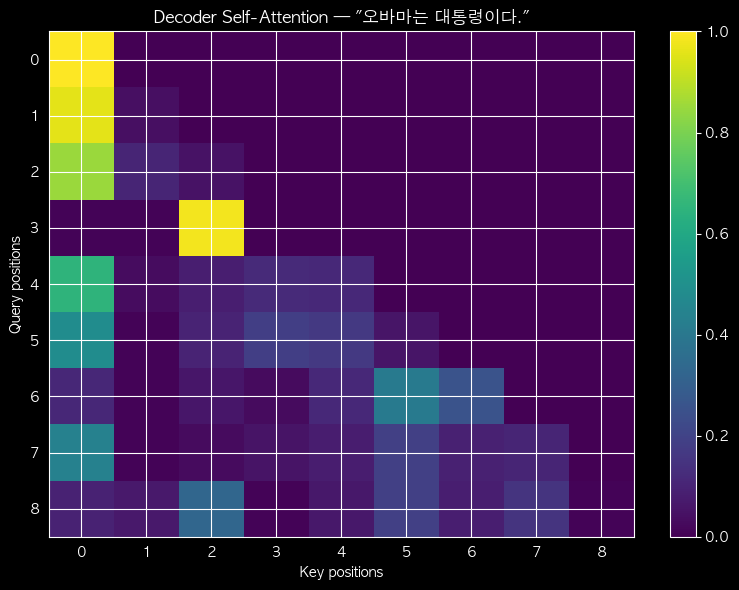

'obamas first president is the president .'

In [95]:
# Cell 19
translate('오바마는 대통령이다.', transformer, ko_tokenizer, en_tokenizer, plot_attention=True)